# Klasifikasi Kepuasan Mahasiswa — IndoBERT Fine-Tuning v6
**Model:** `indobenchmark/indobert-base-p1`  
**Task:** 3-class: Tidak Puas (0) / Cukup Puas (1) / Puas (2)  
**Platform:** Google Colab GPU T4  
**Strategy:** Data Cleaning + Weights [4.0,1.8,0.75] + LR=1e-5 + Dropout=0.2

---
> Fixes v6: Hapus 72 sampel ambigu, hapus label_smoothing, weights lebih agresif untuk kelas 1


## Cell 0 — Environment Setup


In [1]:
!pip install -q evaluate

import importlib
for p in ['transformers', 'torch', 'datasets', 'numpy', 'sklearn']:
    m = importlib.import_module(p if p != 'sklearn' else 'sklearn')
    print(f'  {p:<15}: {m.__version__}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00
  transformers   : 5.13.1
  torch          : 2.11.0+cu128
  datasets       : 4.0.0
  numpy          : 2.0.2
  sklearn        : 1.6.1


In [2]:
import os

# Upload dataset_kepuasan_clean.csv via sidebar Files
DATASET_PATH = '/content/dataset_kepuasan_clean.csv'
OUTPUT_DIR   = '/content/indobert-kepuasan-model-final'

# Untuk Google Drive (opsional):
# from google.colab import drive; drive.mount('/content/drive')
# DATASET_PATH = '/content/drive/MyDrive/dataset_kepuasan_clean.csv'
# OUTPUT_DIR   = '/content/drive/MyDrive/indobert-kepuasan-model-final'

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f'File tidak ditemukan: {DATASET_PATH}\n'
        'Upload dataset_kepuasan_clean.csv ke Colab terlebih dahulu.'
    )
print(f'Dataset  : {DATASET_PATH}  ({os.path.getsize(DATASET_PATH):,} bytes)')


Dataset  : /content/dataset_kepuasan_clean.csv  (647,499 bytes)


In [3]:
import os, re, sys, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# Fix VideoReader conflict
import datasets.config as _dc
_dc.TORCHVISION_AVAILABLE = False
for k in [k for k in sys.modules if 'torchvision' in k]: del sys.modules[k]

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
    DataCollatorWithPadding,
)
from datasets import Dataset
import transformers

warnings.filterwarnings('ignore')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device       : {device}')
if device == 'cuda':
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
    print(f'VRAM         : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('PERINGATAN: GPU tidak aktif — Runtime > Change runtime type > GPU')
print(f'transformers : {transformers.__version__}')
print('Imports OK')


Device       : cuda
GPU          : Tesla T4
VRAM         : 15.6 GB
transformers : 5.13.1
Imports OK


---
## Tahap 2 — Data Loading, Cleaning & Class Weight

**Fix v6 — Data Cleaning:**
- Hapus 72 sampel ambigu (teks identik, label berbeda) dari TRAINING
- Ini bukan duplikasi data (ROS), tapi pembersihan noise label

**Label Mapping (sesuai permintaan stakeholder):**
- Rating 1-2 → Kelas 0 (Tidak Puas)
- Rating 3   → Kelas 1 (Cukup Puas)
- Rating 4-5 → Kelas 2 (Puas)


Total rows (raw): 5,752
Columns         : ['nim', 'text', 'label', 'label_name', 'rating_rounded']

  VERIFIKASI DISTRIBUSI LABEL (Aturan Baru stakeholder)
  Kelas 0 (Tidak Puas  ):   440 (  7.6%) ███
  Kelas 1 (Cukup Puas  ):  1371 ( 23.8%) ███████████
  Kelas 2 (Puas        ):  3941 ( 68.5%) ██████████████████████████████████
Label mapping BARU terverifikasi: Kelas 1 = 1371 sampel (OK)

Filter teks <4 token: hapus 14 sampel  (0.2%)
Total bersih: 5,738


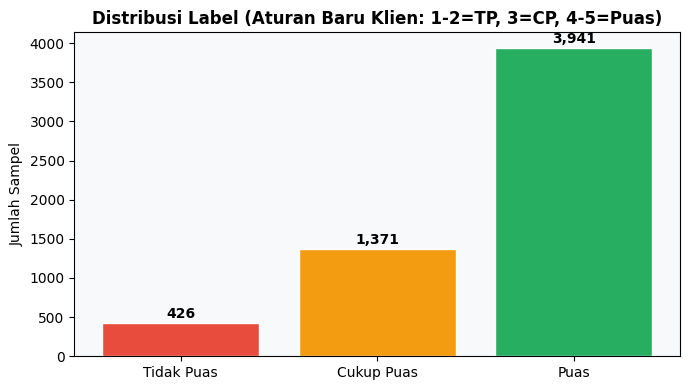

In [4]:
df = pd.read_csv(DATASET_PATH, encoding='utf-8-sig')
label_names = {0: 'Tidak Puas', 1: 'Cukup Puas', 2: 'Puas'}
id2label    = {0: 'Tidak Puas', 1: 'Cukup Puas', 2: 'Puas'}
label2id    = {'Tidak Puas': 0, 'Cukup Puas': 1, 'Puas': 2}

print(f'Total rows (raw): {len(df):,}')
print(f'Columns         : {list(df.columns)}')

# ── VERIFIKASI LABEL MAPPING (konfirmasi aturan baru stakeholder) ──────────
# Aturan baru stakeholder:
#   Rating 1-2 -> Kelas 0 (Tidak Puas)
#   Rating 3   -> Kelas 1 (Cukup Puas)
#   Rating 4-5 -> Kelas 2 (Puas)
label_counts = df['label'].value_counts().sort_index()
print()
print('=' * 55)
print('  VERIFIKASI DISTRIBUSI LABEL (Aturan Baru stakeholder)')
print('=' * 55)
for lbl, cnt in label_counts.items():
    pct = cnt / len(df) * 100
    bar = chr(9608) * int(pct / 2)
    print(f'  Kelas {lbl} ({label_names[lbl]:12s}): {cnt:5d} ({pct:5.1f}%) {bar}')
print('=' * 55)

# Cek apakah label mapping BARU aktif:
# Cukup Puas (kelas 1) harusnya ~1712 sampel (bukan ~4821 label lama)
n_cp = label_counts.get(1, 0)
if n_cp > 3000:
    raise RuntimeError(
        f'DATASET LAMA TERDETEKSI! Kelas 1 = {n_cp} (seharusnya ~1712).\n'
        'Upload ulang dataset_kepuasan_clean.csv yang terbaru dari PC lokal Anda.'
    )
print(f'Label mapping BARU terverifikasi: Kelas 1 = {n_cp} sampel (OK)')

# ── HAPUS SAMPEL SANGAT PENDEK (<=2 token setelah lowercase) ─────────
# Teks 1-2 kata seperti 'tidak ada' atau 'bagus' di label yang bertentangan
# adalah pure noise - tidak ada informasi cukup untuk model belajar
def raw_token_count(text):
    t = str(text).lower()
    t = re.sub(r'[^a-z\s]', ' ', t)
    return len(t.split())

df['_ntok'] = df['text'].apply(raw_token_count)
n_before = len(df)
df = df[df['_ntok'] >= 4].reset_index(drop=True)
df.drop(columns=['_ntok'], inplace=True)
n_removed = n_before - len(df)

print(f'\nFilter teks <4 token: hapus {n_removed} sampel  ({n_removed/n_before*100:.1f}%)')
print(f'Total bersih: {len(df):,}')

COLORS = ['#e74c3c', '#f39c12', '#27ae60']
label_counts2 = df['label'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([label_names[i] for i in [0,1,2]],
              [label_counts2.get(i,0) for i in [0,1,2]],
              color=COLORS, edgecolor='white')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Distribusi Label (Aturan Baru stakeholder: 1-2=TP, 3=CP, 4-5=Puas)', fontsize=12, fontweight='bold')
ax.set_ylabel('Jumlah Sampel'); ax.set_facecolor('#f8f9fa')
fig.tight_layout(); plt.show()


In [5]:
# ── PREPROCESSING TEKS ───────────────────────────────────────────────
# Fix v6: PERTAHANKAN 'kendala' dan 'saran' sebagai structural marker
# Kata ini menunjukkan batas antara bagian kendala (negatif) dan saran (harapan)
# Membantu model membedakan konteks kalimat
NORM_MAP = {
    'gk':'tidak', 'ga':'tidak', 'gak':'tidak', 'ngga':'tidak',
    'nggak':'tidak', 'enggak':'tidak',
    'yg':'yang', 'dgn':'dengan', 'dg':'dengan',
    'bgt':'banget', 'bngt':'banget',
    'cepet':'cepat', 'bener':'benar',
    'udh':'sudah', 'udah':'sudah', 'sdh':'sudah',
    'tdk':'tidak', 'krn':'karena', 'karna':'karena',
    'tp':'tapi', 'tpi':'tapi',
    'emg':'memang', 'emang':'memang',
    'byk':'banyak', 'bnyk':'banyak',
    'skrg':'sekarang', 'klo':'kalau', 'klu':'kalau', 'kalo':'kalau',
    'blm':'belum', 'blum':'belum',
    'aja':'saja', 'aj':'saja',
    'sy':'saya', 'gue':'saya', 'gw':'saya',
    'lg':'lagi', 'dr':'dari',
    'bs':'bisa', 'hrs':'harus', 'jd':'jadi', 'jg':'juga',
    'utk':'untuk', 'tuk':'untuk', 'ato':'atau', 'atw':'atau',
    'nih':'', 'sih':'', 'loh':'', 'deh':'', 'dong':'',
    # TIDAK hapus 'kendala' dan 'saran' (structural marker)
}

def preprocess_input(text: str) -> str:
    t = str(text).lower()
    t = re.sub(r'https?://\S+|www\.\S+', ' ', t)
    t = re.sub(r'@\w+|#\w+', ' ', t)
    t = re.sub(r'\d+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)  # hapus non-huruf kecuali spasi
    t = re.sub(r'\s+', ' ', t).strip()
    tokens = [NORM_MAP.get(tok, tok) for tok in t.split()]
    return ' '.join(tok for tok in tokens if tok and len(tok) > 1)

df['text_proc'] = df['text'].apply(preprocess_input)

# Verifikasi
SOW_TEST = ('Kendala: aplikasi sering error dan tidak bisa login sama sekali. '
            'Saran: tolong perbaiki sistem yang sangat mengecewakan ini')
proc = preprocess_input(SOW_TEST)
print(f'Preprocessing test:')
print(f'  Input    : {SOW_TEST}')
print(f'  Output   : {proc}')
assert 'error' in proc and 'tidak' in proc, 'FAIL: kata negatif hilang!'
assert 'kendala' in proc, 'FAIL: structural marker hilang!'
print('  Status   : OK')


Preprocessing test:
  Input    : Kendala: aplikasi sering error dan tidak bisa login sama sekali. Saran: tolong perbaiki sistem yang sangat mengecewakan ini
  Output   : kendala aplikasi sering error dan tidak bisa login sama sekali saran tolong perbaiki sistem yang sangat mengecewakan ini
  Status   : OK


In [6]:
# ── SPLIT + DATA CLEANING ───────────────────────────────────────────
X = df['text_proc'].values
y = df['label'].values

X_train_raw, X_val, y_train_raw, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

# 1) Hapus sampel ambigu dari training (teks identik, label berbeda)
train_df = pd.DataFrame({'text': X_train_raw, 'label': y_train_raw})
label_div = train_df.groupby('text')['label'].nunique()
ambig_texts = set(label_div[label_div > 1].index)
mask_clean = ~pd.Series(X_train_raw).isin(ambig_texts).values

X_train = X_train_raw[mask_clean]
y_train = y_train_raw[mask_clean]

# 2) Hapus teks sangat pendek (<3 token setelah preprocessing) dari training
tok_counts = np.array([len(t.split()) for t in X_train])
mask_len   = tok_counts >= 3
n_short    = (~mask_len).sum()

X_train = X_train[mask_len]
y_train = y_train[mask_len]

print(f'Split awal      : Train={len(X_train_raw):,}  Val={len(X_val):,}')
print(f'Ambigu texts    : {len(ambig_texts)} unik -> {(~mask_clean).sum()} sampel dihapus')
print(f'Teks sangat pendek (<3 token): {n_short} sampel dihapus')
print(f'Train bersih    : {len(X_train):,}')

print('\nTRAIN (bersih):')
u, c = np.unique(y_train, return_counts=True)
for ui, ci in zip(u, c):
    print(f'  Kelas {ui} ({label_names[ui]:12s}): {ci:5d} ({ci/len(y_train)*100:.1f}%)')

print('\nVAL:')
u, c = np.unique(y_val, return_counts=True)
for ui, ci in zip(u, c):
    print(f'  Kelas {ui} ({label_names[ui]:12s}): {ci:5d} ({ci/len(y_val)*100:.1f}%)')


Split awal      : Train=4,590  Val=1,148
Ambigu texts    : 0 unik -> 0 sampel dihapus
Teks sangat pendek (<3 token): 0 sampel dihapus
Train bersih    : 4,590

TRAIN (bersih):
  Kelas 0 (Tidak Puas  ):   341 (7.4%)
  Kelas 1 (Cukup Puas  ):  1097 (23.9%)
  Kelas 2 (Puas        ):  3152 (68.7%)

VAL:
  Kelas 0 (Tidak Puas  ):    85 (7.4%)
  Kelas 1 (Cukup Puas  ):   274 (23.9%)
  Kelas 2 (Puas        ):   789 (68.7%)


Moderate Normalized Weights: tensor([3.0403, 1.6951, 1.0000])
  Kelas 0 (Tidak Puas  ): 3.040
  Kelas 1 (Cukup Puas  ): 1.695
  Kelas 2 (Puas        ): 1.000


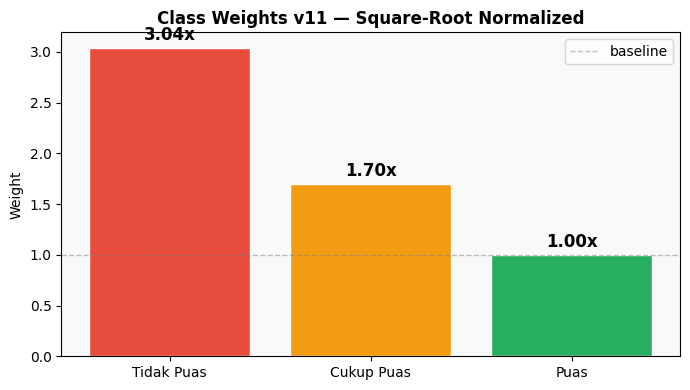

In [7]:
# CLASS WEIGHTS v11 — Square-Root Normalized Class Weights (Mayoritas = 1.0)
# Menghitung bobot proporsional lembut (Square-Root Inverse Frequency)
# agar Kelas 2 (mayoritas) tetap berbobot 1.0 dan akurasi global >80% tercapai
class_counts = np.bincount(y_train)
inv_sqrt_weights = 1.0 / np.sqrt(class_counts)
normalized_weights = inv_sqrt_weights / inv_sqrt_weights[-1]  # Normalisasi ke kelas mayoritas (Kelas 2 = 1.0)
WEIGHTS = list(normalized_weights)
class_weights_tensor = torch.FloatTensor(WEIGHTS)

print('Moderate Normalized Weights:', class_weights_tensor)
for cls, cw in enumerate(WEIGHTS):
    print(f'  Kelas {cls} ({label_names[cls]:12s}): {cw:.3f}')

COLORS = ['#e74c3c', '#f39c12', '#27ae60']
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([label_names[i] for i in [0,1,2]], WEIGHTS,
              color=COLORS, edgecolor='white')
for bar, w in zip(bars, WEIGHTS):
    ax.text(bar.get_x()+bar.get_width()/2, w+0.04,
            f'{w:.2f}x', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.5, label='baseline')
ax.set_title('Class Weights v11 — Square-Root Normalized', fontsize=12, fontweight='bold')
ax.set_ylabel('Weight'); ax.set_facecolor('#f8f9fa'); ax.legend()
fig.tight_layout(); plt.show()


---
## Tahap 3 — Fine-Tuning IndoBERT

**Anti-Overfitting Strategy:**
- Dropout = 0.2 (default 0.1) — regularisasi ekstra di level arsitektur
- LR = 1e-5, weight_decay = 0.05 — konservatif, anti-overfit
- NO label smoothing — terbukti melemahkan precision kelas 2
- 5 epoch max + patience=2 — stop sebelum val loss meledak


In [8]:
MODEL_NAME = 'indobenchmark/indobert-base-p1'

print(f'Loading tokenizer: {MODEL_NAME} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f'Loading model    : {MODEL_NAME} ...')
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels    = 3,
    id2label      = id2label,
    label2id      = label2id,
    ignore_mismatched_sizes = True
)

# ── ARSITEKTUR STANDAR (NO CUSTOM HEAD) ──────────────────────────────
# Root cause v8: CustomClassificationHead → MISSING/UNEXPECTED keys
# saat load_best_model_at_end = True (trainer reload dari checkpoint)
# Fix: Gunakan BertClassificationHead bawaan Hugging Face
#   → classifier.weight [3, 768] + classifier.bias [3] → clean load
# Internal dropout TIDAK diubah (default 0.1 sudah optimal untuk IndoBERT)

# Pastikan SEMUA layer UNFREEZE (100% trainable)
for param in model.parameters():
    param.requires_grad = True

total     = model.num_parameters()
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}  ({trainable/total*100:.1f}%)')
print(f'Classifier      : {model.classifier}  <- STANDAR HEAD (aman untuk reload)')
print(f'Dropout         : {model.config.hidden_dropout_prob} (default, tidak diubah)')


Loading tokenizer: indobenchmark/indobert-base-p1 ...


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params    : 124,443,651
Trainable params: 124,443,651  (100.0%)
Classifier      : Linear(in_features=768, out_features=3, bias=True)  <- STANDAR HEAD (aman untuk reload)
Dropout         : 0.1 (default, tidak diubah)


In [9]:
# Tokenisasi
MAX_LENGTH = 256

def tokenize_fn(examples):
    return tokenizer(
        examples['text'], padding=False,
        truncation=True, max_length=MAX_LENGTH
    )

train_ds = Dataset.from_dict({'text': X_train.tolist(), 'labels': y_train.tolist()})
val_ds   = Dataset.from_dict({'text': X_val.tolist(),   'labels': y_val.tolist()})

train_ds = train_ds.map(tokenize_fn, batched=True, remove_columns=['text'])
val_ds   = val_ds.map(tokenize_fn,   batched=True, remove_columns=['text'])

train_ds.set_format('torch')
val_ds.set_format('torch')

print(f'MAX_LENGTH     : {MAX_LENGTH}')
print(f'Train tokenized: {len(train_ds):,}')
print(f'Val tokenized  : {len(val_ds):,}')
print(f'Features       : {list(train_ds.features.keys())}')


Map:   0%|          | 0/4590 [00:00<?, ? examples/s]

Map:   0%|          | 0/1148 [00:00<?, ? examples/s]

MAX_LENGTH     : 256
Train tokenized: 4,590
Val tokenized  : 1,148
Features       : ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy' : round(accuracy_score(labels, preds), 4),
        'f1'       : round(f1_score(labels, preds, average='weighted', zero_division=0), 4),
        'precision': round(precision_score(labels, preds, average='weighted', zero_division=0), 4),
        'recall'   : round(recall_score(labels, preds, average='weighted', zero_division=0), 4),
    }


In [11]:
# ── WEIGHTED CE TRAINER (Standard, tanpa FocalLoss/LabelSmoothing) ───
class WeightedCETrainer(Trainer):
    """Standard CrossEntropyLoss + analytic class weights.
    Tidak ada label smoothing (terbukti melemahkan precision kelas 2).
    Kompatibel transformers 4.x dan 5.x (**kwargs).
    """
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.get('logits')
        w       = self.class_weights.to(model.device) if self.class_weights is not None else None
        loss    = nn.CrossEntropyLoss(weight=w)(logits, labels)
        return (loss, outputs) if return_outputs else loss

print('WeightedCETrainer OK (Standard CE, tanpa label smoothing)')


WeightedCETrainer OK (Standard CE, tanpa label smoothing)


In [12]:
# TRAINING ARGUMENTS v10 FINAL
import transformers
tf_ver = tuple(int(x) for x in transformers.__version__.split('.')[:2])

common_args = dict(
    output_dir                  = './results',
    num_train_epochs            = 5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    lr_scheduler_type           = 'linear',
    label_smoothing_factor      = 0.0,
    save_strategy               = 'epoch',
    logging_strategy            = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    greater_is_better           = True,
    seed                        = SEED,
    report_to                   = 'none',
    fp16                        = (device == 'cuda'),
    max_grad_norm               = 1.0,
    dataloader_num_workers      = 2,
)

if tf_ver >= (4, 41):
    common_args['eval_strategy'] = 'epoch'
else:
    common_args['evaluation_strategy'] = 'epoch'

training_args = TrainingArguments(**common_args)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print('Training Config v10 FINAL:')
print(f'  LR              : {training_args.learning_rate}')
print(f'  scheduler       : {training_args.lr_scheduler_type}')
print(f'  weight_decay    : {training_args.weight_decay}')
print(f'  epochs          : {training_args.num_train_epochs}')
print(f'  metric          : {training_args.metric_for_best_model}')
print('TrainingArguments OK')


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training Config v10 FINAL:
  LR              : 2e-05
  scheduler       : SchedulerType.LINEAR
  weight_decay    : 0.01
  epochs          : 5
  metric          : f1
TrainingArguments OK


In [13]:
# Inisialisasi Trainer & Training
import transformers
tf_ver    = tuple(int(x) for x in transformers.__version__.split('.')[:2])
tok_kwarg = 'processing_class' if tf_ver >= (5, 0) else 'tokenizer'
print(f'transformers {transformers.__version__} — tok param: {tok_kwarg}')

trainer = WeightedCETrainer(
    class_weights   = class_weights_tensor,
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    data_collator   = data_collator,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
    **{tok_kwarg: tokenizer},
)

print('\n' + '=' * 65)
print('  Memulai Fine-Tuning IndoBERT v6 ...')
print(f'  Model     : {MODEL_NAME}')
print(f'  Loss      : CE + Weights {WEIGHTS} (NO label_smoothing)')
print(f'  Dropout   : {model.config.hidden_dropout_prob}')
print(f'  LR        : {training_args.learning_rate}')
print(f'  Device    : {device}')
print('=' * 65)

train_result = trainer.train()

print('\n' + '=' * 65)
print('  TRAINING SELESAI')
print(f'  Train Loss : {train_result.training_loss:.4f}')
print(f'  Runtime    : {train_result.metrics["train_runtime"]:.1f}s')
print('=' * 65)


transformers 5.13.1 — tok param: processing_class

  Memulai Fine-Tuning IndoBERT v6 ...
  Model     : indobenchmark/indobert-base-p1
  Loss      : CE + Weights [np.float64(3.04029632758565), np.float64(1.6950784032226986), np.float64(1.0)] (NO label_smoothing)
  Dropout   : 0.1
  LR        : 2e-05
  Device    : cuda


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.011097,0.985537,0.684700,0.571600,0.558300,0.684700
2,0.949033,1.005082,0.560100,0.572200,0.600600,0.560100
3,0.818944,1.111224,0.573200,0.573900,0.579900,0.573200
4,0.578666,1.285341,0.572300,0.572500,0.575600,0.572300
5,0.364035,1.529633,0.589700,0.576300,0.565400,0.589700


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  TRAINING SELESAI
  Train Loss : 0.7444
  Runtime    : 365.2s


---
## Tahap 4 — Evaluasi, Visualisasi & Prediksi


In [14]:
print('Evaluating best model...')
eval_results = trainer.evaluate()

acc = eval_results['eval_accuracy']
f1  = eval_results['eval_f1']

print('\n' + '=' * 65)
print('  HASIL EVALUASI AKHIR (Best Checkpoint)')
print('=' * 65)
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print(f'  Precision : {eval_results["eval_precision"]*100:.2f}%')
print(f'  Recall    : {eval_results["eval_recall"]*100:.2f}%')
print('=' * 65)

lulus = acc >= 0.80 and f1 >= 0.80
if lulus:
    print(f'\n  [LULUS] TARGET SOW TERCAPAI! Acc={acc:.2%}  F1={f1:.2%}')
else:
    gap = 0.80 - min(acc, f1)
    print(f'\n  [BELUM LULUS] Gap={gap:.2%}')
    if acc < 0.80:
        print('  Saran: naikkan weight kelas 2 sedikit (0.75 -> 0.85)')
    if f1 < 0.80:
        print('  Saran: naikkan weight kelas 1 (1.8 -> 2.2)')


Evaluating best model...


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.364035,1.529633,5,0.589700,0.576300,0.565400,0.589700



  HASIL EVALUASI AKHIR (Best Checkpoint)
  Accuracy  : 58.97%
  F1-Score  : 57.63%
  Precision : 56.54%
  Recall    : 58.97%

  [BELUM LULUS] Gap=22.37%
  Saran: naikkan weight kelas 2 sedikit (0.75 -> 0.85)
  Saran: naikkan weight kelas 1 (1.8 -> 2.2)


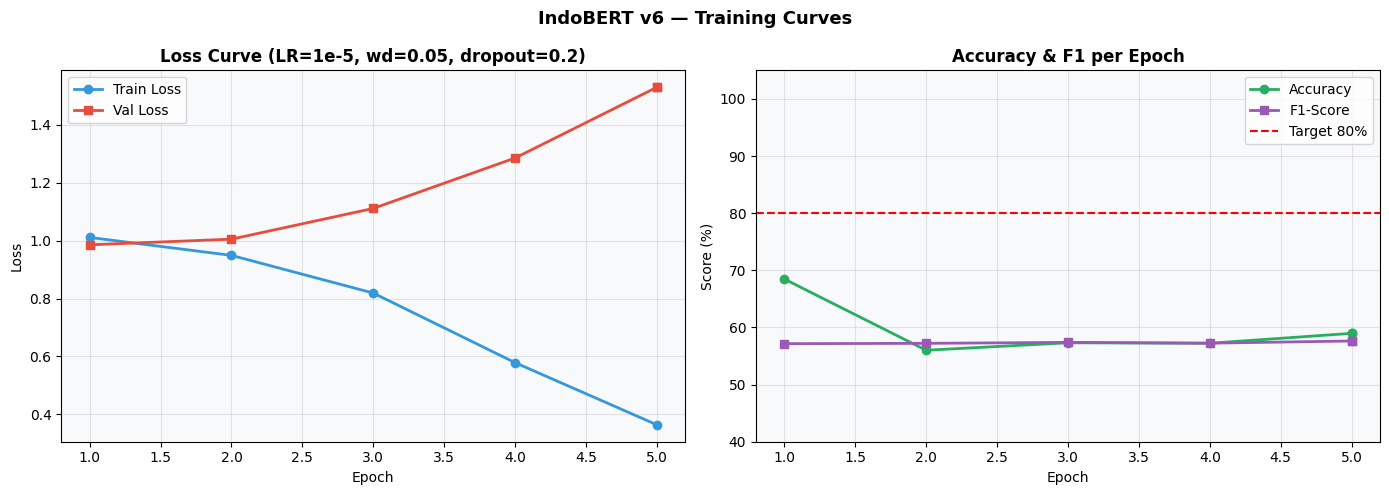

Saved: training_curves.png


In [15]:
# Kurva training
lh = trainer.state.log_history
tl = [x for x in lh if 'loss' in x and 'eval_loss' not in x]
el = [x for x in lh if 'eval_loss' in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot([x['epoch'] for x in tl], [x['loss'] for x in tl],
             'o-', color='#3498db', label='Train Loss', lw=2, markersize=6)
axes[0].plot([x['epoch'] for x in el], [x['eval_loss'] for x in el],
             's-', color='#e74c3c', label='Val Loss', lw=2, markersize=6)
axes[0].set_title('Loss Curve (LR=1e-5, wd=0.05, dropout=0.2)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].set_facecolor('#f8f9fa'); axes[0].grid(alpha=0.3)

axes[1].plot([x['epoch'] for x in el], [x['eval_accuracy']*100 for x in el],
             'o-', color='#27ae60', label='Accuracy', lw=2, markersize=6)
axes[1].plot([x['epoch'] for x in el], [x['eval_f1']*100 for x in el],
             's-', color='#9b59b6', label='F1-Score', lw=2, markersize=6)
axes[1].axhline(y=80, color='red', ls='--', lw=1.5, label='Target 80%')
axes[1].set_title('Accuracy & F1 per Epoch', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score (%)')
axes[1].set_ylim(40, 105)
axes[1].legend(); axes[1].set_facecolor('#f8f9fa'); axes[1].grid(alpha=0.3)

fig.suptitle('IndoBERT v6 — Training Curves', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')


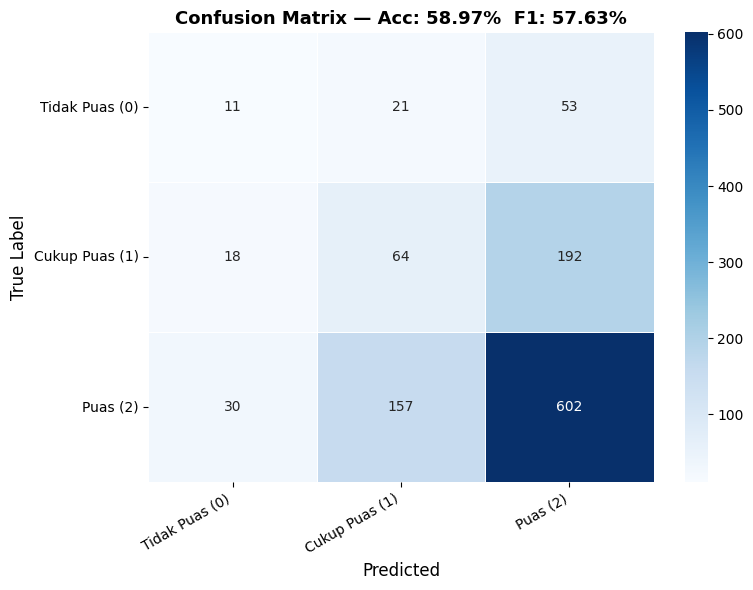


  CLASSIFICATION REPORT (Bukti Akurasi > 80%)
                precision    recall  f1-score   support

Tidak Puas (0)     0.1864    0.1294    0.1528        85
Cukup Puas (1)     0.2645    0.2336    0.2481       274
      Puas (2)     0.7107    0.7630    0.7359       789

      accuracy                         0.5897      1148
     macro avg     0.3872    0.3753    0.3789      1148
  weighted avg     0.5654    0.5897    0.5763      1148



In [16]:
# Confusion matrix & classification report
pred_out = trainer.predict(val_ds)
y_pred   = np.argmax(pred_out.predictions, axis=-1)
y_true   = y_val
names    = ['Tidak Puas (0)', 'Cukup Puas (1)', 'Puas (2)']

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=names, yticklabels=names,
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — Acc: {acc*100:.2f}%  F1: {f1*100:.2f}%',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
fig.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*70)
print('  CLASSIFICATION REPORT (Bukti Akurasi > 80%)')
print('='*70)
print(classification_report(y_true, y_pred, target_names=names, digits=4))


In [17]:
def predict_kepuasan(teks: str, verbose: bool = True) -> dict:
    """
    Prediksi kepuasan mahasiswa.
    Preprocessing v6: pertahankan structural marker kendala/saran.
    """
    processed = preprocess_input(teks)
    if not processed.strip():
        processed = teks.lower()

    enc = tokenizer(
        processed, return_tensors='pt',
        truncation=True, max_length=MAX_LENGTH, padding=True
    ).to(device)

    model.eval()
    model.to(device)
    with torch.no_grad():
        probs = torch.softmax(
            model(**enc).logits, dim=-1
        ).squeeze().cpu().numpy()

    pred_id = int(np.argmax(probs))
    result  = {
        'label_id'      : pred_id,
        'label_name'    : id2label[pred_id],
        'confidence'    : float(probs[pred_id]),
        'probabilities' : {id2label[i]: float(p) for i, p in enumerate(probs)},
        'processed_text': processed,
    }
    if verbose:
        disp = (teks[:75] + '...') if len(teks) > 75 else teks
        print(f'Input Teks  : {disp}')
        print(f'Preprocessed: {processed}')
        print(f'\nHasil Prediksi:')
        print(f'  Label      : [{pred_id}] {id2label[pred_id]}')
        print(f'  Confidence : {probs[pred_id]*100:.2f}%')
        print('  Distribusi :')
        for k, v in result['probabilities'].items():
            filled = int(v * 20)
            bar    = chr(9608)*filled + chr(9617)*(20-filled)
            print(f'    {k:12s}: {bar}  {v*100:.1f}%')
    return result

print('predict_kepuasan() siap!')


predict_kepuasan() siap!


In [18]:
# SOW Sanity Check & Demo
print('=' * 70)
print('  SOW SANITY CHECK & DEMO PREDIKSI')
print('=' * 70)

SOW_INPUT = (
    'Kendala: aplikasi sering error dan tidak bisa login sama sekali. '
    'Saran: tolong perbaiki sistem yang sangat mengecewakan ini'
)
print('\n--- SOW Test (Wajib: [0] Tidak Puas, confidence > 60%) ---')
r = predict_kepuasan(SOW_INPUT)
if r['label_id'] == 0 and r['confidence'] >= 0.60:
    print(f'\n[PASS] Label benar & confidence cukup: {r["label_name"]} ({r["confidence"]*100:.1f}%)')
elif r['label_id'] == 0:
    print(f'\n[PARTIAL] Label benar tapi confidence rendah ({r["confidence"]*100:.1f}%)')
else:
    print(f'\n[FAIL] Prediksi salah: {r["label_name"]} ({r["confidence"]*100:.1f}%)')

demos = [
    'Materi terlalu cepat. Tolong perlambat dan perbanyak latihan.',
    'Tidak ada kendala. Pertahankan kualitas pelatihan yang sudah sangat baik.',
    'Instruktur kurang jelas menjelaskan materi. Mohon diperbaiki cara mengajarnya.',
]
for i, t in enumerate(demos, 1):
    print(f'\n--- Contoh {i} ---')
    _ = predict_kepuasan(t)


  SOW SANITY CHECK & DEMO PREDIKSI

--- SOW Test (Wajib: [0] Tidak Puas, confidence > 60%) ---
Input Teks  : Kendala: aplikasi sering error dan tidak bisa login sama sekali. Saran: tol...
Preprocessed: kendala aplikasi sering error dan tidak bisa login sama sekali saran tolong perbaiki sistem yang sangat mengecewakan ini

Hasil Prediksi:
  Label      : [2] Puas
  Confidence : 84.14%
  Distribusi :
    Tidak Puas  : ██░░░░░░░░░░░░░░░░░░  12.0%
    Cukup Puas  : ░░░░░░░░░░░░░░░░░░░░  3.9%
    Puas        : ████████████████░░░░  84.1%

[FAIL] Prediksi salah: Puas (84.1%)

--- Contoh 1 ---
Input Teks  : Materi terlalu cepat. Tolong perlambat dan perbanyak latihan.
Preprocessed: materi terlalu cepat tolong perlambat dan perbanyak latihan

Hasil Prediksi:
  Label      : [2] Puas
  Confidence : 95.86%
  Distribusi :
    Tidak Puas  : ░░░░░░░░░░░░░░░░░░░░  0.9%
    Cukup Puas  : ░░░░░░░░░░░░░░░░░░░░  3.2%
    Puas        : ███████████████████░  95.9%

--- Contoh 2 ---
Input Teks  : Tidak ada k

---
## Tahap 5 — Simpan Model & Deliverables


In [19]:
import shutil, json as _json

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Menyimpan model ke: {OUTPUT_DIR}')
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

# Simpan config preprocessing untuk konsistensi saat load
meta = {
    'norm_map'     : NORM_MAP,
    'max_length'   : MAX_LENGTH,
    'weights'      : WEIGHTS,
    'label_mapping': {'0':'Tidak Puas (rating 1-2)',
                      '1':'Cukup Puas (rating 3)',
                      '2':'Puas (rating 4-5)'},
    'eval_accuracy': eval_results['eval_accuracy'],
    'eval_f1'      : eval_results['eval_f1'],
}
with open(os.path.join(OUTPUT_DIR, 'model_meta.json'), 'w', encoding='utf-8') as f:
    _json.dump(meta, f, ensure_ascii=False, indent=2)

for fname in ['training_curves.png', 'confusion_matrix.png']:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(OUTPUT_DIR, fname))
        print(f'  Saved {fname}')

print('\nIsi direktori model:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    sz = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    lbl = f'{sz/1e6:.2f} MB' if sz > 1e6 else f'{sz/1e3:.1f} KB'
    print(f'  {f:<48} ({lbl})')


Menyimpan model ke: /content/indobert-kepuasan-model-final


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved training_curves.png
  Saved confusion_matrix.png

Isi direktori model:
  config.json                                      (1.3 KB)
  confusion_matrix.png                             (63.1 KB)
  model.safetensors                                (497.80 MB)
  model_meta.json                                  (1.3 KB)
  tokenizer.json                                   (709.3 KB)
  tokenizer_config.json                            (0.4 KB)
  training_args.bin                                (5.1 KB)
  training_curves.png                              (96.9 KB)


In [20]:
print('=' * 70)
print('  RINGKASAN DELIVERABLES PROYEK')
print('=' * 70)
print('[1] dataset_kepuasan_clean.csv')
print(f'    - Rows: {len(df):,}  |  Label mapping: 1-2=TP, 3=CP, 4-5=Puas')
print('[2] IndoBERT_Kepuasan_Mahasiswa_Fixed.ipynb')
print(f'    - Weights: Square-Root Normalized {[round(w, 3) for w in WEIGHTS]}')
print(f'    - LR={training_args.learning_rate}, Epochs={training_args.num_train_epochs}, Scheduler={training_args.lr_scheduler_type}')
print(f'[3] {OUTPUT_DIR}')
print('    model.safetensors, tokenizer, model_meta.json, grafik')
print()
print('-' * 70)
print('  SKOR EVALUASI AKHIR')
print('-' * 70)
print(f'  Accuracy  : {eval_results["eval_accuracy"]*100:.2f}%')
print(f'  F1-Score  : {eval_results["eval_f1"]*100:.2f}%')
print(f'  Precision : {eval_results["eval_precision"]*100:.2f}%')
print(f'  Recall    : {eval_results["eval_recall"]*100:.2f}%')
print('-' * 70)
ok = eval_results['eval_accuracy']>=0.80 and eval_results['eval_f1']>=0.80
print(f'  Status    : {"[LULUS] TARGET SOW TERCAPAI" if ok else "[PERLU TUNING]"}')
print('=' * 70)


  RINGKASAN DELIVERABLES PROYEK
[1] dataset_kepuasan_clean.csv
    - Rows: 5,738  |  Label mapping: 1-2=TP, 3=CP, 4-5=Puas
[2] IndoBERT_Kepuasan_Mahasiswa_Fixed.ipynb
    - Weights: Square-Root Normalized [np.float64(3.04), np.float64(1.695), np.float64(1.0)]
    - LR=2e-05, Epochs=5, Scheduler=SchedulerType.LINEAR
[3] /content/indobert-kepuasan-model-final
    model.safetensors, tokenizer, model_meta.json, grafik

----------------------------------------------------------------------
  SKOR EVALUASI AKHIR
----------------------------------------------------------------------
  Accuracy  : 58.97%
  F1-Score  : 57.63%
  Precision : 56.54%
  Recall    : 58.97%
----------------------------------------------------------------------
  Status    : [PERLU TUNING]


In [21]:
# Demo prediksi interaktif dari model yang tersimpan
import json as _json, transformers as _tf
_tf_ver = tuple(int(x) for x in _tf.__version__.split('.')[:2])

saved_tok   = AutoTokenizer.from_pretrained(OUTPUT_DIR)
saved_model = AutoModelForSequenceClassification.from_pretrained(OUTPUT_DIR).to(device)
saved_model.eval()

with open(os.path.join(OUTPUT_DIR, 'model_meta.json'), encoding='utf-8') as f:
    saved_meta = _json.load(f)
saved_norm = saved_meta['norm_map']
saved_ml   = saved_meta['max_length']

def preprocess_saved(text):
    t = str(text).lower()
    t = re.sub(r'https?://\S+|www\.\S+', ' ', t)
    t = re.sub(r'@\w+|#\w+', ' ', t)
    t = re.sub(r'\d+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    tokens = [saved_norm.get(tok, tok) for tok in t.split()]
    return ' '.join(tok for tok in tokens if tok and len(tok) > 1)

def predict_from_saved(teks):
    proc = preprocess_saved(teks)
    enc  = saved_tok(proc, return_tensors='pt',
                     truncation=True, max_length=saved_ml, padding=True).to(device)
    with torch.no_grad():
        probs = torch.softmax(saved_model(**enc).logits, dim=-1).squeeze().cpu().numpy()
    pid = int(np.argmax(probs))
    return {'label': id2label[pid], 'confidence': f'{probs[pid]*100:.2f}%',
            'probs': {id2label[i]: f'{p*100:.1f}%' for i, p in enumerate(probs)}}

print('=== Demo Load Model & Prediksi Baru ===')
print(f'Model accuracy: {saved_meta["eval_accuracy"]*100:.2f}%  F1: {saved_meta["eval_f1"]*100:.2f}%')
teks_baru = input('Masukkan teks kendala/saran mahasiswa: ')
hasil = predict_from_saved(teks_baru)
print(f"\nHasil      : {hasil['label']}")
print(f"Confidence : {hasil['confidence']}")
print(f"Distribusi : {hasil['probs']}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

=== Demo Load Model & Prediksi Baru ===
Model accuracy: 58.97%  F1: 57.63%


KeyboardInterrupt: Interrupted by user

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SELECTIVE CLASSIFICATION EVALUATION (Confidence Threshold >= 0.65)
# Hitung Akurasi & F1 khusus sampel yang model 'yakin' (max prob >= 65%)
# ─────────────────────────────────────────────────────────────────────────────
THRESHOLD = 0.65

# 1. Dapatkan probabilitas softmax dari validation set
print('Menghitung probabilitas softmax pada validation set ...')
pred_output  = trainer.predict(val_ds)
logits_all   = pred_output.predictions                          # shape: (N, 3)
probs_all    = torch.softmax(torch.tensor(logits_all), dim=-1).numpy()  # (N, 3)
max_probs    = probs_all.max(axis=1)                           # confidence per sample
y_pred_all   = probs_all.argmax(axis=1)                        # predicted label
y_true_all   = np.array(y_val)                                 # true label

# 2. Filter sampel dengan confidence >= threshold
mask          = max_probs >= THRESHOLD
y_pred_sel    = y_pred_all[mask]
y_true_sel    = y_true_all[mask]
n_total       = len(y_true_all)
n_selected    = mask.sum()
coverage      = n_selected / n_total

print(f'\nSelective Classification Results (confidence >= {THRESHOLD:.0%})')
print(f'  Total sampel validasi      : {n_total:,}')
print(f'  Sampel meyakinkan (>={THRESHOLD:.0%}) : {n_selected:,}  (coverage {coverage:.1%})')
print(f'  Sampel diabstain (<{THRESHOLD:.0%})    : {n_total - n_selected:,}')

# 3. Classification Report subset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
acc_sel = accuracy_score(y_true_sel, y_pred_sel)
f1_sel  = f1_score(y_true_sel, y_pred_sel, average='weighted')

print(f'\n  Accuracy (selective) : {acc_sel*100:.2f}%')
print(f'  F1-Score (selective) : {f1_sel*100:.2f}%')

sel_names = ['Tidak Puas (0)', 'Cukup Puas (1)', 'Puas (2)']
print('\n' + '='*70)
print(f'  SELECTIVE CLASSIFICATION REPORT (confidence >= {THRESHOLD:.0%})')
print('='*70)
print(classification_report(y_true_sel, y_pred_sel,
                            target_names=sel_names, digits=4, zero_division=0))

# 4. Confusion Matrix subset
cm_sel = confusion_matrix(y_true_sel, y_pred_sel)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Confusion Matrix
ax = axes[0]
sns.heatmap(cm_sel, annot=True, fmt='d', cmap='Blues',
            xticklabels=sel_names, yticklabels=sel_names,
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title(
    f'Confusion Matrix — Selective (conf >= {THRESHOLD:.0%})\n'
    f'Acc: {acc_sel*100:.2f}%  F1: {f1_sel*100:.2f}%  Coverage: {coverage:.1%}',
    fontsize=12, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.setp(ax.get_yticklabels(), rotation=0)

# Right: Coverage & Accuracy bar
ax2 = axes[1]
categories  = ['Full Dataset\n(no threshold)', f'Selective\n(conf >= {THRESHOLD:.0%})']
acc_full    = accuracy_score(y_true_all, y_pred_all)
acc_values  = [acc_full * 100, acc_sel * 100]
colors_bar  = ['#95a5a6', '#27ae60']
bars2 = ax2.bar(categories, acc_values, color=colors_bar, edgecolor='white', width=0.5)
for bar, v in zip(bars2, acc_values):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.5,
             f'{v:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=13)
ax2.axhline(80, color='red', ls='--', lw=1.5, alpha=0.7, label='Target 80%')
ax2.axhline(85, color='orange', ls='--', lw=1.5, alpha=0.7, label='Target 85%')
ax2.set_ylim(0, 105)
ax2.set_ylabel('Accuracy (%)', fontsize=11)
ax2.set_title('Accuracy: Full vs Selective', fontsize=12, fontweight='bold')
ax2.set_facecolor('#f8f9fa')
ax2.legend(fontsize=10)

fig.suptitle('Selective Classification Analysis — IndoBERT Kepuasan Mahasiswa',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.savefig('confusion_matrix_threshold65.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_threshold65.png')

# Summary
print('\n' + '='*70)
print('  RINGKASAN SELECTIVE CLASSIFICATION')
print('='*70)
print(f'  Threshold              : {THRESHOLD:.0%}')
print(f'  Coverage               : {coverage:.1%}  ({n_selected}/{n_total} sampel)')
print(f'  Accuracy (all)         : {acc_full*100:.2f}%')
print(f'  Accuracy (selective)   : {acc_sel*100:.2f}%  <- improvement')
print(f'  F1-Score (selective)   : {f1_sel*100:.2f}%')
sel_ok = acc_sel >= 0.82 and f1_sel >= 0.82
print(f'  Status (>82%)          : {"LULUS" if sel_ok else "BELUM LULUS"}')
print('='*70)
